# Combined Chromatin Deconvolution Run
March 7, 2024

Trial combined chromatin deconvolution model run

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import load_yl_rg1_vst_config
from cc_src.combined_chromatin_model import CombinedChromatinModel

config1 = load_yl_rg1_vst_config(1)
config2 = load_yl_rg1_vst_config(2)
combined_model = CombinedChromatinModel(config1, config2)


In [162]:

def deconvolve_combined(gene_name, outdir):
    combined_model.load_combined_mnase_gene(gene_name)
    # Deconvolve
    combined_model.deconvolve(verbose=True)
    fig = combined_model.plot_raw_prediction(1, vmax=50)
    fig = combined_model.plot_raw_prediction(2, vmax=50)

    # Deconvolve the combined gene expression model
    from src.config import load_combined_yl_alpha_vst_gene_expression_config
    from src.model import Model

    combined_ge_config = load_combined_yl_alpha_vst_gene_expression_config()
    ge_model = Model(combined_ge_config, gene_name)
    ge_model.deconvolve_find_optimal_gamma()

    fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=50, ge_model=ge_model)
    plt.savefig(f"{outdir}/{gene_name}_deconvolution.png", dpi=150)
    plt.close(fig)
    plt.close()
    
    fig = combined_model.plot_raw_prediction(1, vmax=50)
    plt.savefig(f"{outdir}/{gene_name}_rep1.png", dpi=150)
    plt.close(fig)
    plt.close()
    
    fig = combined_model.plot_raw_prediction(2, vmax=50)
    plt.savefig(f"{outdir}/{gene_name}_rep2.png", dpi=150)
    plt.close(fig)
    plt.close()
    
    return combined_model, combined_ge_config


In [164]:
from src.utils import mkdirs_safe
outdir = 'output/deconvolution_results_006_2024-03-08'

mkdirs_safe([outdir])

for gene_name in ['SSK22', 'CLB2', 'SSK22', 'FIG1', 'DSE2', "RNR3"]:
    combined_model, combined_ge_config = deconvolve_combined(gene_name, outdir)


Creating directory: output/deconvolution_results_006_2024-03-08...Directory exists. Skipping.
Loading MNase reads for YCR073C/SSK22...Already loaded chromosome reads for 3. Using cache.
Done.
Loading MNase reads for YCR073C/SSK22...Already loaded chromosome reads for 3. Using cache.
Done.
Deconvolving combined model with gamma=0.006, gamma_prime=0
Deconvolving bin size: 32x32
of G shape: (31, 200)
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Mar 08 02:59:46 PM: Your problem has 45400 variables, 1 constraints, and 1 parameters.
(CVXPY) Mar 08 02:59:46 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 08 02:59:46 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 08 02:59:46 PM: Your problem is compiled with the CPP canonicalization backend.
----------------------------------------

(CVXPY) Mar 08 03:00:10 PM: 23  3.3e-04  3.3e-04  2.4e-05  4.02e-01   2.159217552e+03   2.159217519e+03   3.3e-04  8.23  
(CVXPY) Mar 08 03:00:10 PM: 24  2.0e-04  2.0e-04  1.3e-05  3.92e-01   2.140317701e+03   2.140317587e+03   2.0e-04  8.35  
(CVXPY) Mar 08 03:00:11 PM: 25  1.8e-04  1.8e-04  1.1e-05  4.10e-01   2.134915152e+03   2.134915029e+03   1.8e-04  8.46  
(CVXPY) Mar 08 03:00:11 PM: 26  1.3e-04  1.3e-04  7.6e-06  4.28e-01   2.122738104e+03   2.122737966e+03   1.3e-04  8.56  
(CVXPY) Mar 08 03:00:11 PM: 27  1.1e-04  1.1e-04  5.8e-06  4.74e-01   2.114535360e+03   2.114535217e+03   1.1e-04  8.67  
(CVXPY) Mar 08 03:00:11 PM: 28  8.9e-05  8.9e-05  4.7e-06  4.86e-01   2.108639403e+03   2.108639257e+03   8.9e-05  8.77  
(CVXPY) Mar 08 03:00:11 PM: Optimizer terminated. Time: 8.99    
(CVXPY) Mar 08 03:00:11 PM: 
(CVXPY) Mar 08 03:00:11 PM: 
(CVXPY) Mar 08 03:00:11 PM: Interior-point solution summary
(CVXPY) Mar 08 03:00:11 PM:   Problem status  : PRIMAL_AND_DUAL_FEASIBLE
(CVXPY) Mar 

(CVXPY) Mar 08 03:01:01 PM: 8   2.5e-02  2.5e-02  7.3e-03  1.12e+00   2.284026429e+03   2.284032272e+03   2.5e-02  6.68  
(CVXPY) Mar 08 03:01:01 PM: 9   9.7e-03  9.7e-03  2.2e-03  3.87e-01   2.231752314e+03   2.231753536e+03   9.7e-03  6.84  
(CVXPY) Mar 08 03:01:01 PM: 10  7.6e-03  7.6e-03  1.7e-03  2.23e-01   2.210710073e+03   2.210710878e+03   7.6e-03  6.94  
(CVXPY) Mar 08 03:01:01 PM: 11  4.9e-03  4.9e-03  9.8e-04  2.41e-01   2.171522978e+03   2.171523073e+03   4.9e-03  7.05  
(CVXPY) Mar 08 03:01:01 PM: 12  3.9e-03  3.9e-03  7.3e-04  3.03e-01   2.148708325e+03   2.148708220e+03   3.9e-03  7.16  
(CVXPY) Mar 08 03:01:02 PM: 13  3.0e-03  3.0e-03  5.3e-04  3.28e-01   2.123245691e+03   2.123245426e+03   3.0e-03  7.26  
(CVXPY) Mar 08 03:01:02 PM: 14  2.2e-03  2.2e-03  3.7e-04  3.58e-01   2.093084441e+03   2.093084066e+03   2.2e-03  7.37  
(CVXPY) Mar 08 03:01:02 PM: 15  1.7e-03  1.7e-03  2.6e-04  3.97e-01   2.064846642e+03   2.064846232e+03   1.7e-03  7.48  
(CVXPY) Mar 08 03:01:02 

(CVXPY) Mar 08 03:01:45 PM: Optimizer  - Semi-definite variables: 0                 scalarized             : 0               
(CVXPY) Mar 08 03:01:45 PM: Factor     - setup time             : 1.41            
(CVXPY) Mar 08 03:01:45 PM: Factor     - dense det. time        : 0.00              GP order time          : 0.00            
(CVXPY) Mar 08 03:01:45 PM: Factor     - nonzeros before factor : 6.19e+06          after factor           : 6.19e+06        
(CVXPY) Mar 08 03:01:45 PM: Factor     - dense dim.             : 2                 flops                  : 1.84e+09        
(CVXPY) Mar 08 03:01:45 PM: ITE PFEAS    DFEAS    GFEAS    PRSTATUS   POBJ              DOBJ              MU       TIME  
(CVXPY) Mar 08 03:01:45 PM: 0   1.0e+00  1.0e+00  2.0e+00  0.00e+00   -1.000000000e+00  -0.000000000e+00  1.0e+00  6.01  
(CVXPY) Mar 08 03:01:45 PM: 1   5.9e-01  5.9e-01  1.4e+00  -5.23e-01  1.920238147e+02   1.925181852e+02   5.9e-01  6.24  
(CVXPY) Mar 08 03:01:45 PM: 2   3.5e-01  3.5e-0

(CVXPY) Mar 08 03:02:31 PM:   Integer variables      : 0               
(CVXPY) Mar 08 03:02:31 PM: 
(CVXPY) Mar 08 03:02:31 PM: Optimizer started.
(CVXPY) Mar 08 03:02:31 PM: Presolve started.
(CVXPY) Mar 08 03:02:32 PM: Linear dependency checker started.
(CVXPY) Mar 08 03:02:32 PM: Linear dependency checker terminated.
(CVXPY) Mar 08 03:02:32 PM: Eliminator started.
(CVXPY) Mar 08 03:02:33 PM: Freed constraints in eliminator : 246400
(CVXPY) Mar 08 03:02:33 PM: Eliminator terminated.
(CVXPY) Mar 08 03:02:34 PM: Eliminator started.
(CVXPY) Mar 08 03:02:35 PM: Freed constraints in eliminator : 0
(CVXPY) Mar 08 03:02:35 PM: Eliminator terminated.
(CVXPY) Mar 08 03:02:35 PM: Eliminator - tries                  : 2                 time                   : 0.00            
(CVXPY) Mar 08 03:02:35 PM: Lin. dep.  - tries                  : 1                 time                   : 0.16            
(CVXPY) Mar 08 03:02:35 PM: Lin. dep.  - primal attempts        : 1                 successes 

(CVXPY) Mar 08 03:03:03 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 08 03:03:03 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 08 03:03:03 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Mar 08 03:03:03 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> MOSEK
(CVXPY) Mar 08 03:03:03 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 08 03:03:03 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 08 03:03:03 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 08 03:03:08 PM: Applying reduction MOSEK
(CVXPY) Mar 08 03:03:12 PM: Finished problem compilation (took 9.435e+00 seconds).
(CVXPY) Mar 08 03:03:12 PM: (Subsequent compila

(CVXPY) Mar 08 03:03:28 PM: 30  1.1e-04  1.1e-04  5.6e-06  6.81e-01   2.099629194e+03   2.099629192e+03   1.1e-04  9.20  
(CVXPY) Mar 08 03:03:28 PM: 31  8.8e-05  8.8e-05  4.0e-06  6.98e-01   2.087514753e+03   2.087514731e+03   8.8e-05  9.30  
(CVXPY) Mar 08 03:03:28 PM: Optimizer terminated. Time: 9.52    
(CVXPY) Mar 08 03:03:28 PM: 
(CVXPY) Mar 08 03:03:28 PM: 
(CVXPY) Mar 08 03:03:28 PM: Interior-point solution summary
(CVXPY) Mar 08 03:03:28 PM:   Problem status  : PRIMAL_AND_DUAL_FEASIBLE
(CVXPY) Mar 08 03:03:28 PM:   Solution status : OPTIMAL
(CVXPY) Mar 08 03:03:28 PM:   Primal.  obj: 2.0875147527e+03    nrm: 2e+04    Viol.  con: 2e-04    var: 1e+01    cones: 0e+00  
(CVXPY) Mar 08 03:03:28 PM:   Dual.    obj: 2.0875147315e+03    nrm: 2e+03    Viol.  con: 0e+00    var: 2e-04    cones: 0e+00  
-------------------------------------------------------------------------------
                                    Summary                                    
----------------------------

(CVXPY) Mar 08 03:04:12 PM: 12  2.5e-03  2.5e-03  3.0e-04  3.30e-01   2.305015790e+03   2.305018502e+03   2.5e-03  7.15  
(CVXPY) Mar 08 03:04:12 PM: 13  2.2e-03  2.2e-03  2.6e-04  4.99e-01   2.294745386e+03   2.294747839e+03   2.2e-03  7.25  
(CVXPY) Mar 08 03:04:12 PM: 14  1.7e-03  1.7e-03  1.8e-04  5.19e-01   2.271822724e+03   2.271824637e+03   1.7e-03  7.36  
(CVXPY) Mar 08 03:04:12 PM: 15  1.4e-03  1.4e-03  1.4e-04  5.63e-01   2.255566654e+03   2.255568244e+03   1.4e-03  7.46  
(CVXPY) Mar 08 03:04:12 PM: 16  1.2e-03  1.2e-03  1.1e-04  5.71e-01   2.239708241e+03   2.239709553e+03   1.2e-03  7.57  
(CVXPY) Mar 08 03:04:12 PM: 17  1.0e-03  1.0e-03  9.6e-05  5.77e-01   2.229829191e+03   2.229830348e+03   1.0e-03  7.68  
(CVXPY) Mar 08 03:04:12 PM: 18  8.9e-04  8.9e-04  8.2e-05  5.74e-01   2.219117220e+03   2.219118221e+03   8.9e-04  7.78  
(CVXPY) Mar 08 03:04:12 PM: 19  6.1e-04  6.1e-04  5.0e-05  5.77e-01   2.190233723e+03   2.190234358e+03   6.1e-04  7.93  
(CVXPY) Mar 08 03:04:13 

In [ ]:
from src.dynamic_config_alpha import create_dynamic_alpha_config

ge_config = create_dynamic_alpha_config()

In [78]:
ge_model.gamma

0.00109

In [152]:
combined_ge_config = load_combined_yl_alpha_vst_gene_expression_config()
ge_model = Model(combined_ge_config, "CLB2")

In [153]:
ge_model.gamma = 0.0006
ge_model.deconvolve()

256 512 512


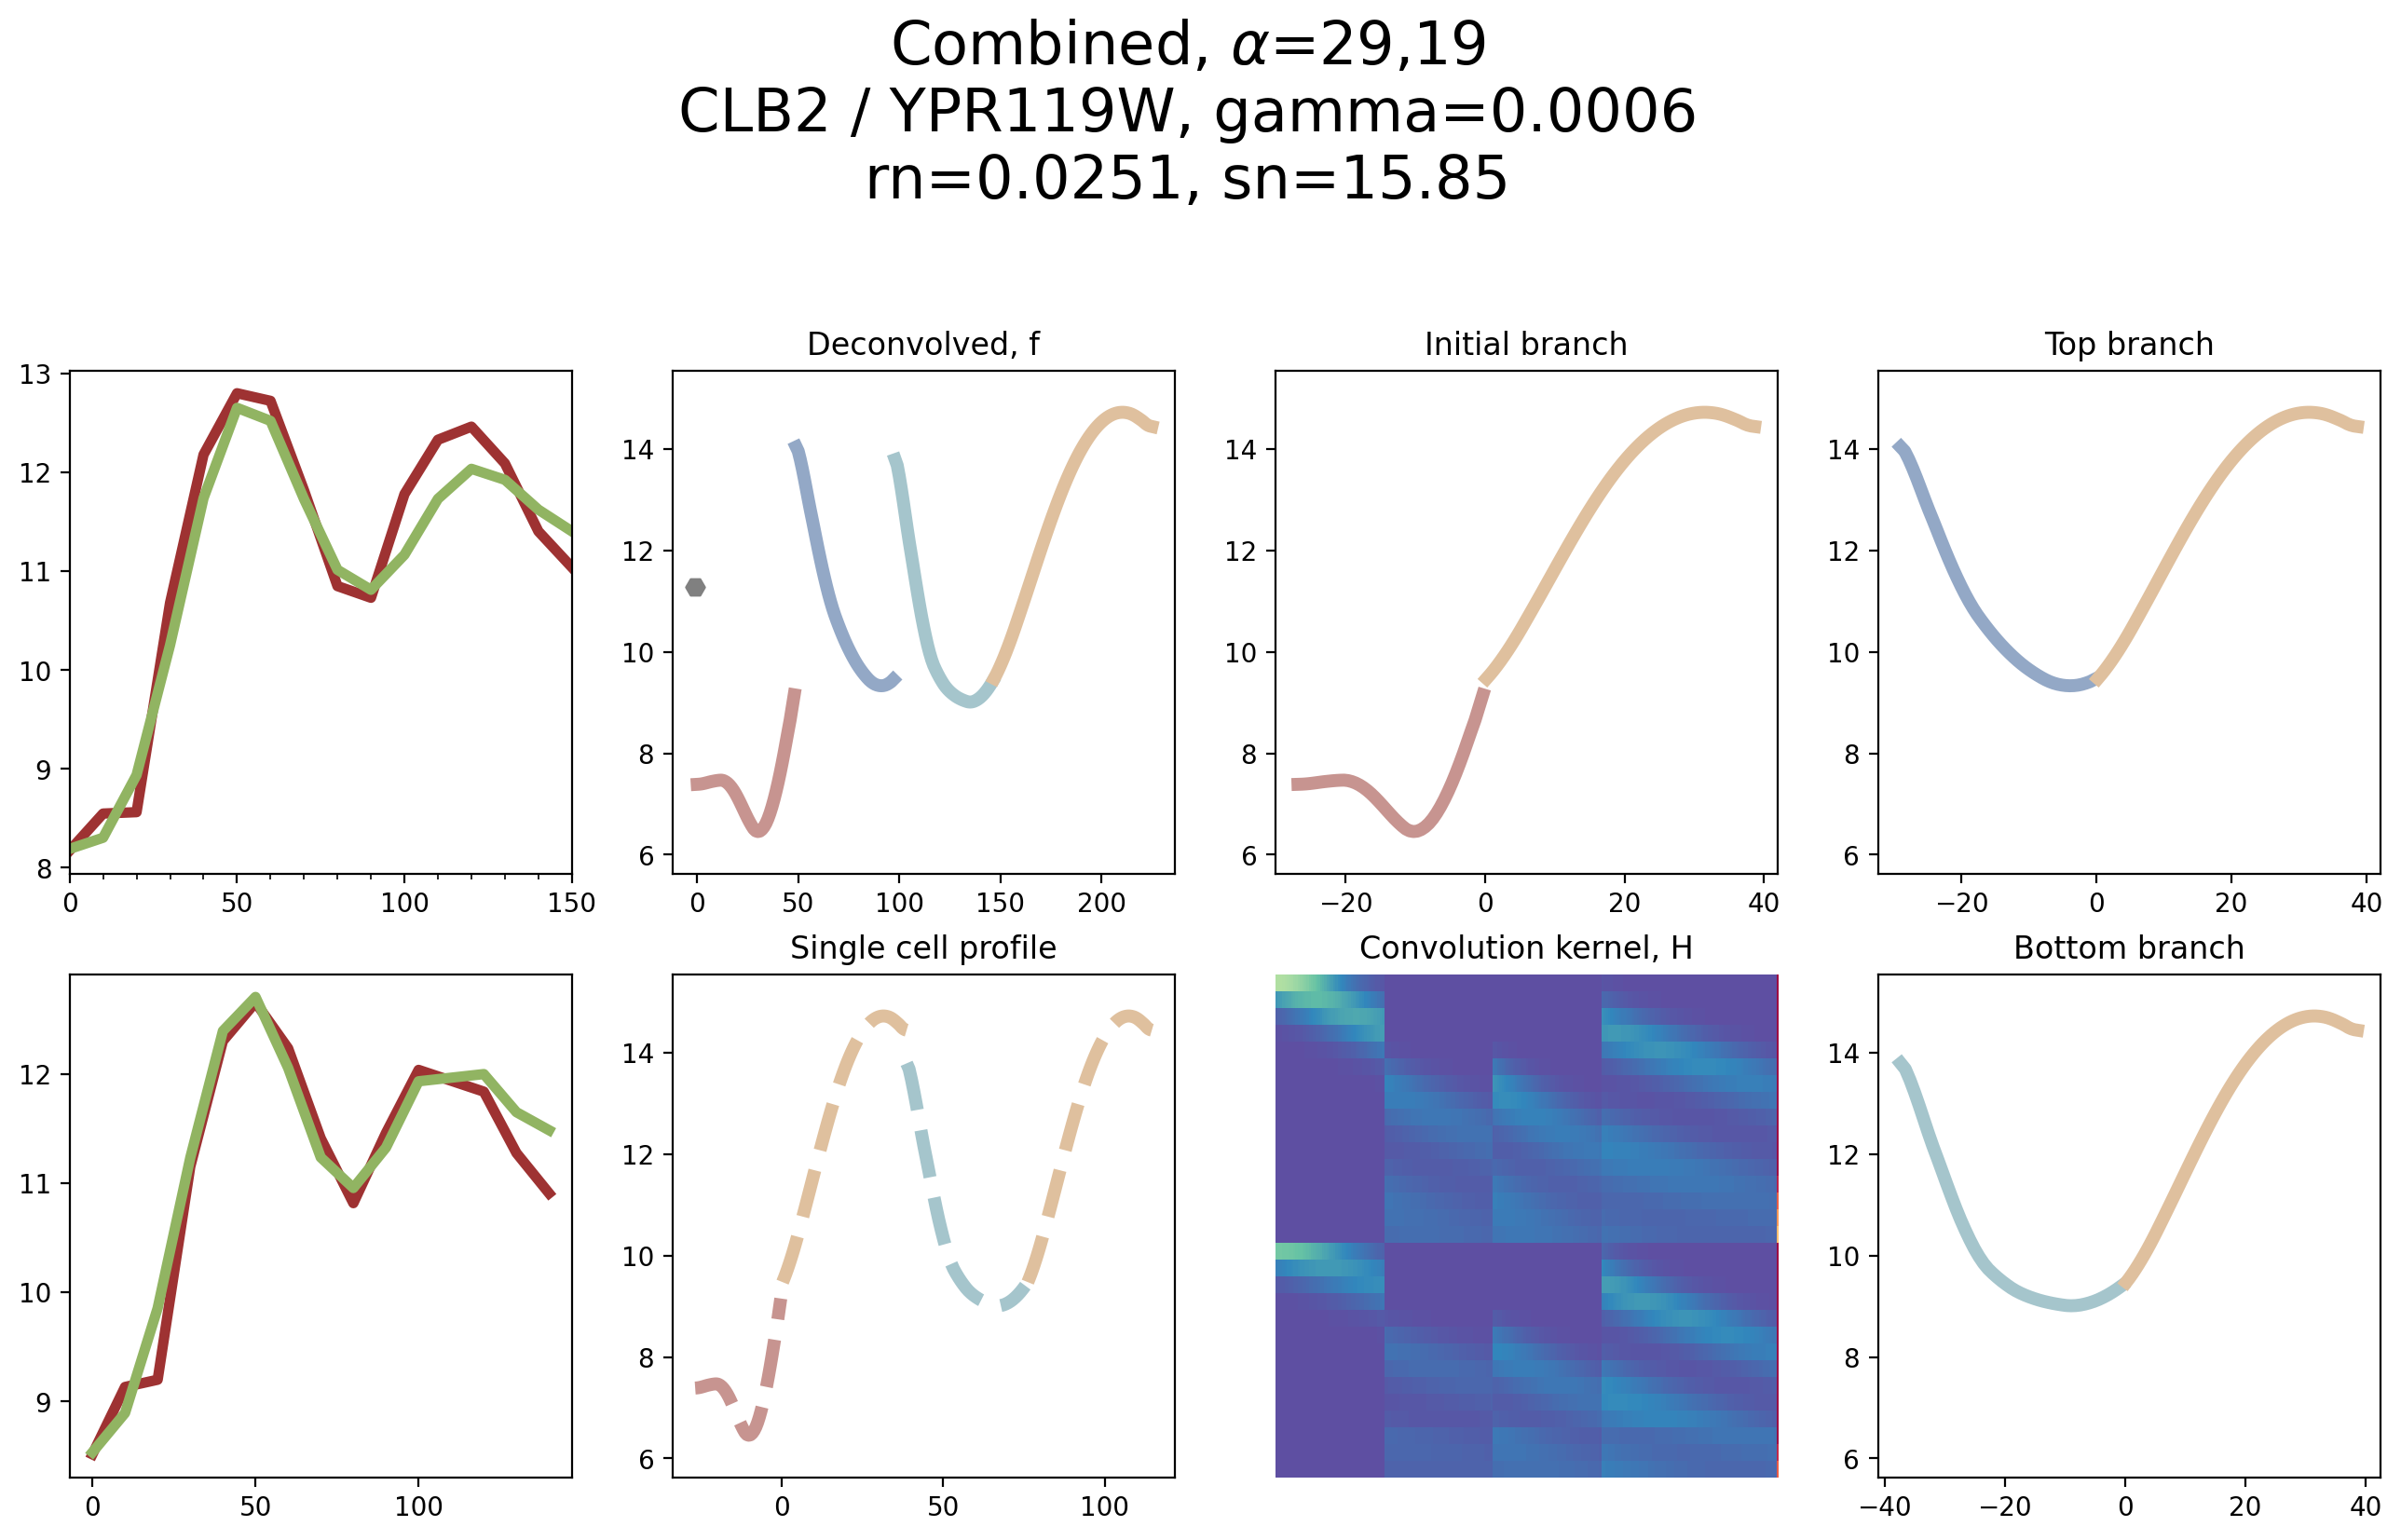

In [154]:
fig = ge_model.plot_deconvolved_gene()

In [157]:
combined_model.load_combined_mnase_gene(ge_model.gene_name)

Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.


In [158]:
combined_model.deconvolve()

Deconvolving combined model with gamma=0.006, gamma_prime=0
Deconvolving bin size: 32x32
of G shape: (31, 200)
Deconvolved in : 00:00:27.86
The fitting norm is 8.05, the smoothing norm is: 18.45


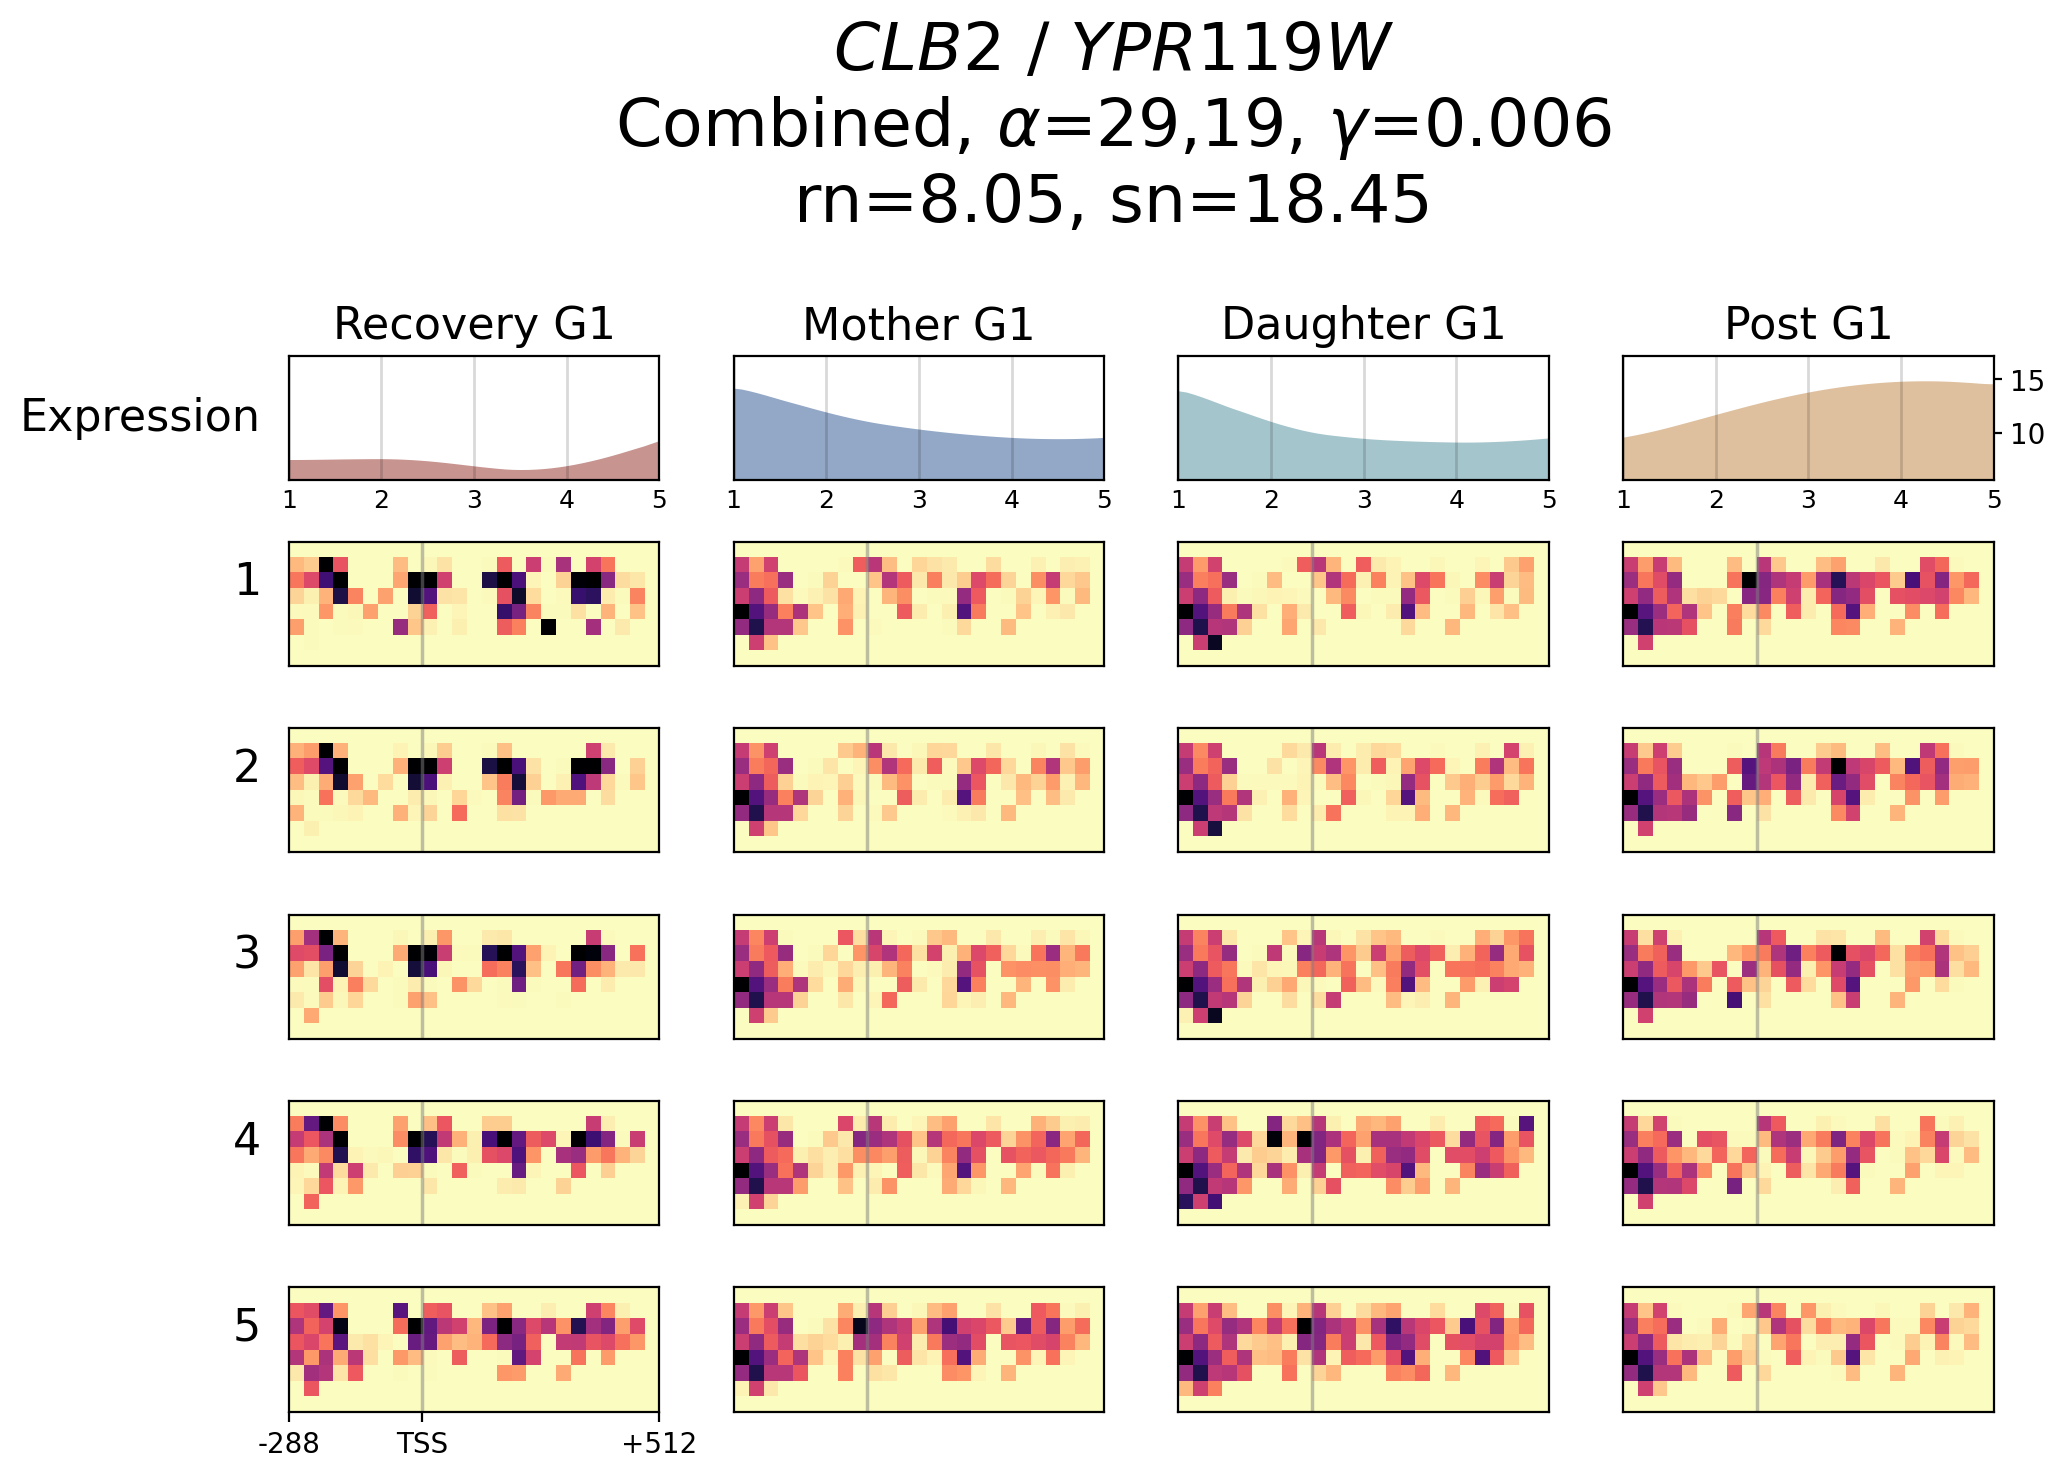

In [159]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(ge_model)

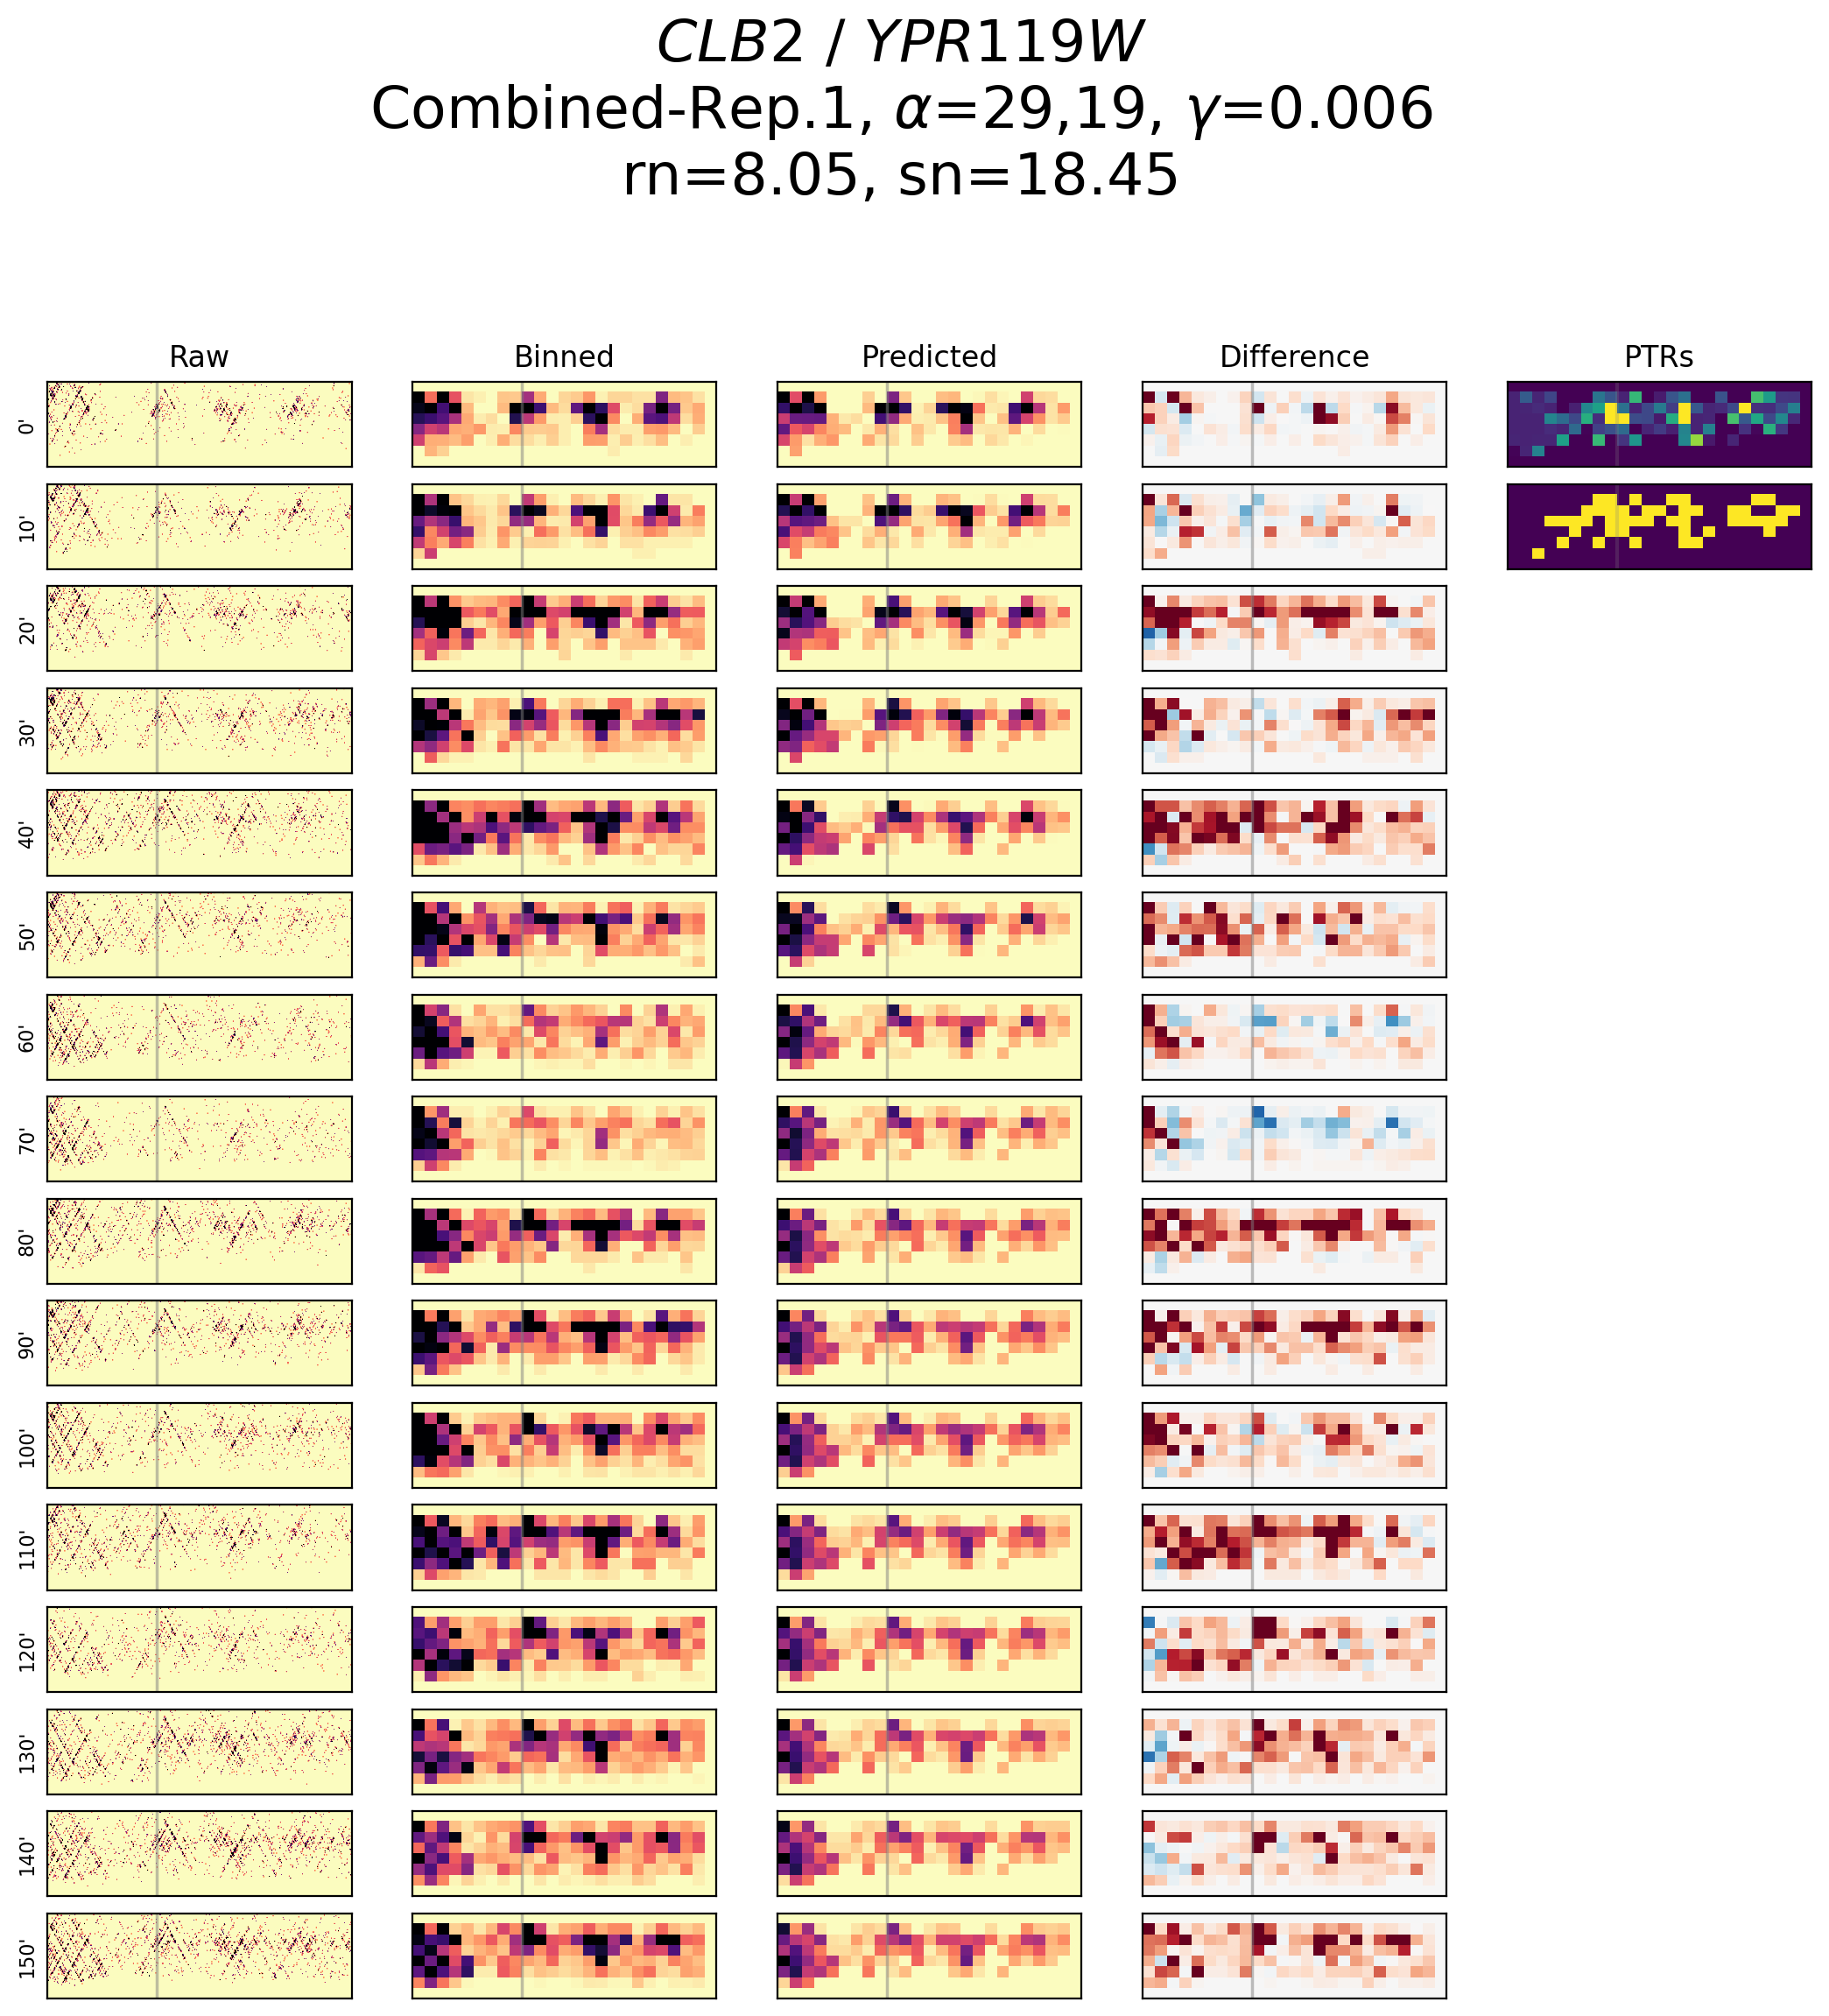

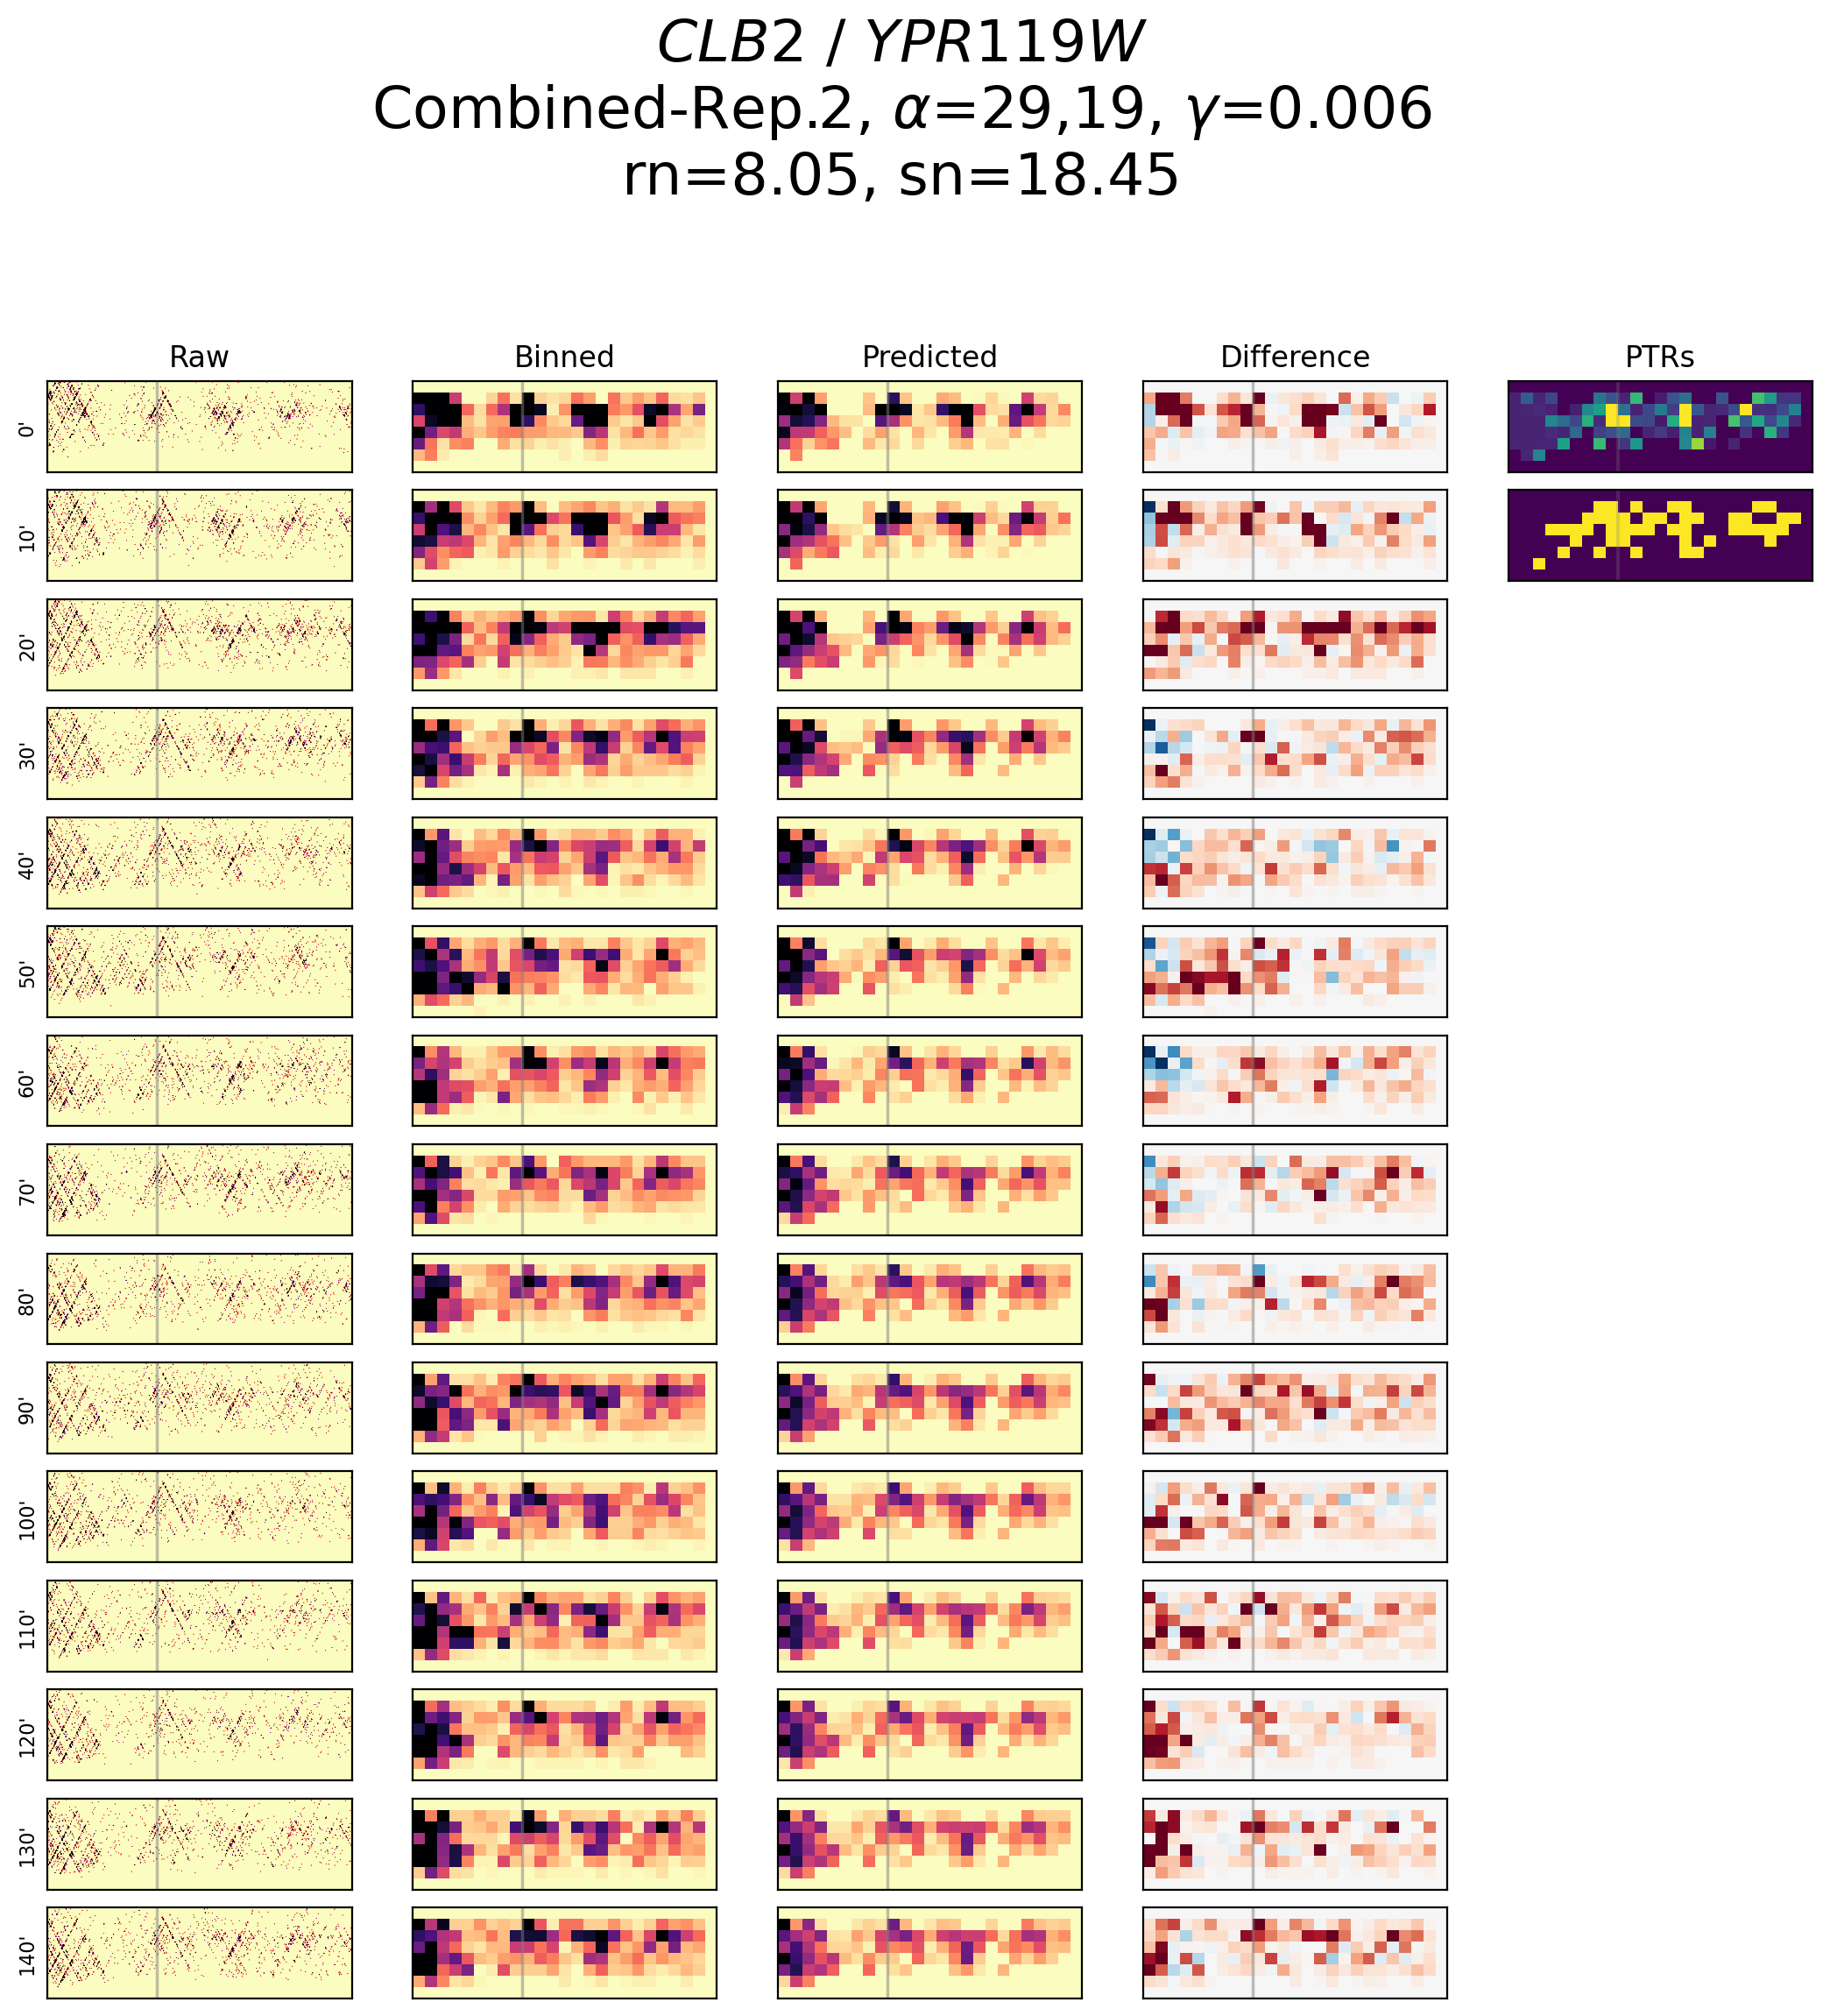

In [161]:
fig = combined_model.plot_raw_prediction(1)
fig = combined_model.plot_raw_prediction(2)